In [1]:
# Run: jupyter notebook visualize_annotations.ipynb
# Requires: pip install pandas matplotlib seaborn

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

with open('annotations.json') as f:
    raw = json.load(f)

# Parse into flat rows
rows = []
for lang_key, entries in raw.items():
    lang = lang_key.replace('uhmazing_v1_', '').upper()
    for entry in entries:
        item_i = entry.get('item_i')
        user_id = entry.get('user_id')
        ann = entry.get('annotation')
        if not isinstance(item_i, int) or not isinstance(ann, list):
            continue
        for ann_dict in ann:
            if not isinstance(ann_dict, dict):
                continue
            for model, mdata in ann_dict.items():
                if not isinstance(mdata, dict) or 'sliders' not in mdata:
                    continue
                sliders = mdata['sliders']
                error_spans = mdata.get('error_spans', [])
                rows.append({
                    'lang': lang,
                    'user_id': user_id,
                    'item_i': item_i,
                    'model': model,
                    'style': sliders.get('Style preservation'),
                    'meaning': sliders.get('Meaning preservation'),
                    'n_errors': len(error_spans),
                    'error_cats': [s.get('category') for s in error_spans],
                    'error_sevs': [s.get('severity') for s in error_spans],
                })

df = pd.DataFrame(rows)
print(f'{len(df)} annotation rows across {df.lang.nunique()} languages, {df.model.nunique()} models')
df.head()

3150 annotation rows across 8 languages, 4 models


,lang,user_id,item_i,model,style,meaning,n_errors,error_cats,error_sevs
0,AR,61..81,0,speechllm/phi_multimodal,26,13,2,"[General/Incorrect language, General/Extra con...","[major, major]"
1,AR,61..81,0,gold_cascaded/tower,80,90,3,"[General/Missing content, General/Incorrect la...","[major, major, major]"
2,AR,61..81,0,end2end/gemini-2.5-flash,50,50,2,"[General/Extra content, Disfluency/Type mismatch]","[major, major]"
3,AR,61..81,1,speechllm/phi_multimodal,80,95,2,"[General/Missing content, General/Missing cont...","[minor, minor]"
4,AR,61..81,1,gold_cascaded/tower,50,40,4,"[General/Incorrect language, General/Incorrect...","[major, major, major, major]"


/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_30204/3312656099.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='model', y=col, ax=ax, palette='Set2')
/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_30204/3312656099.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_30204/3312656099.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='model', y=col, ax=ax, palette='Set2')
/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_30204

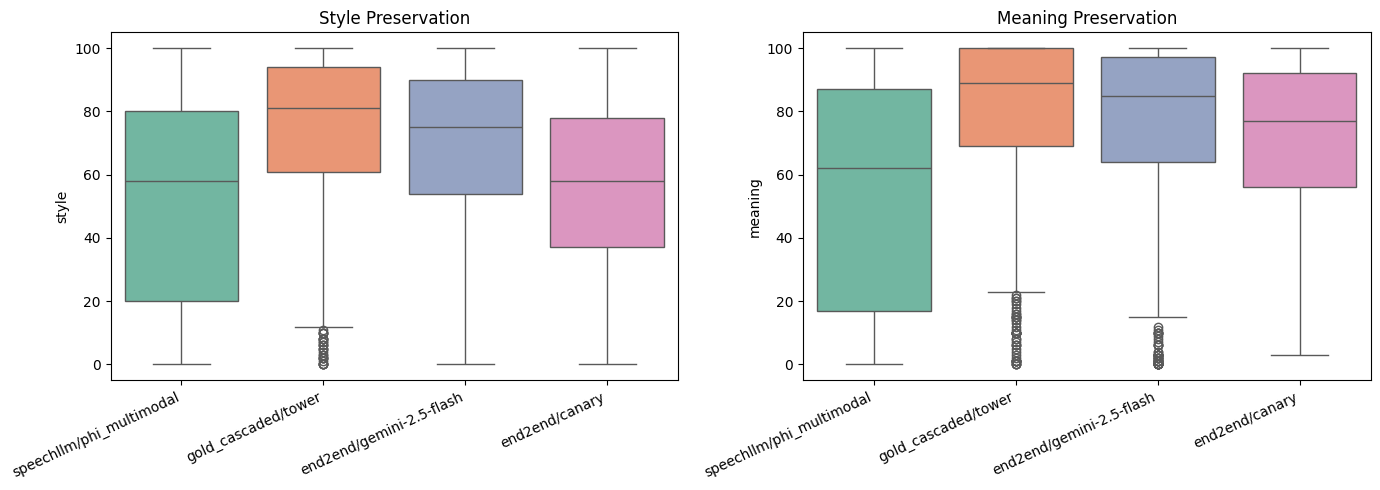

In [2]:
# --- Style & Meaning preservation by model (all languages) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes, ['style', 'meaning'], ['Style Preservation', 'Meaning Preservation']):
    sns.boxplot(data=df, x='model', y=col, ax=ax, palette='Set2')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
    ax.set_ylim(-5, 105)
plt.tight_layout()
plt.show()

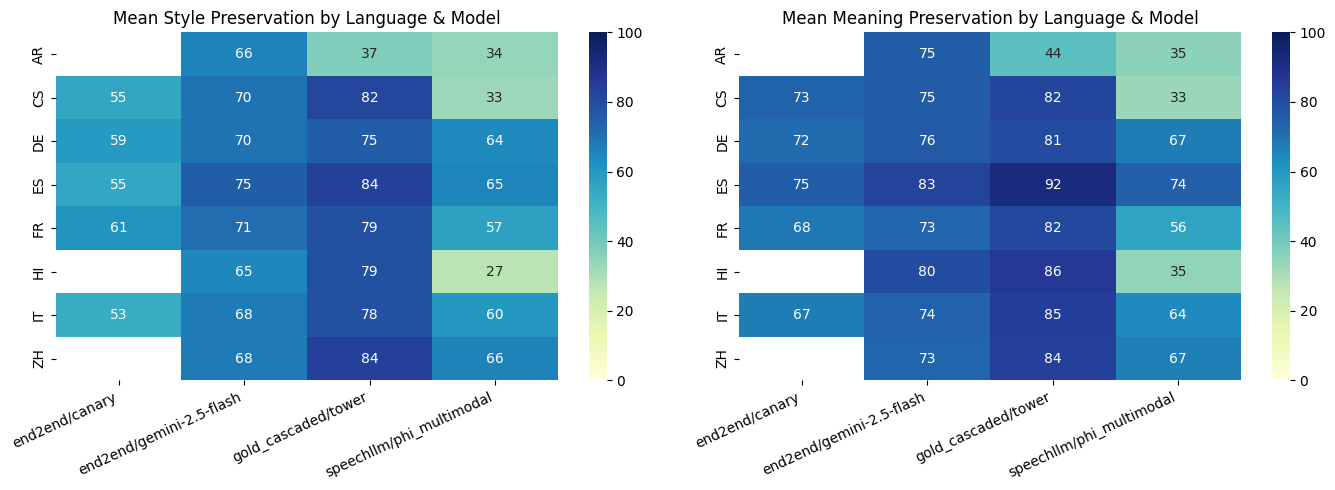

In [3]:
# --- Mean scores per model per language (heatmaps) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes, ['style', 'meaning'], ['Style Preservation', 'Meaning Preservation']):
    pivot = df.pivot_table(index='lang', columns='model', values=col, aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax, vmin=0, vmax=100)
    ax.set_title(f'Mean {title} by Language & Model')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
plt.tight_layout()
plt.show()

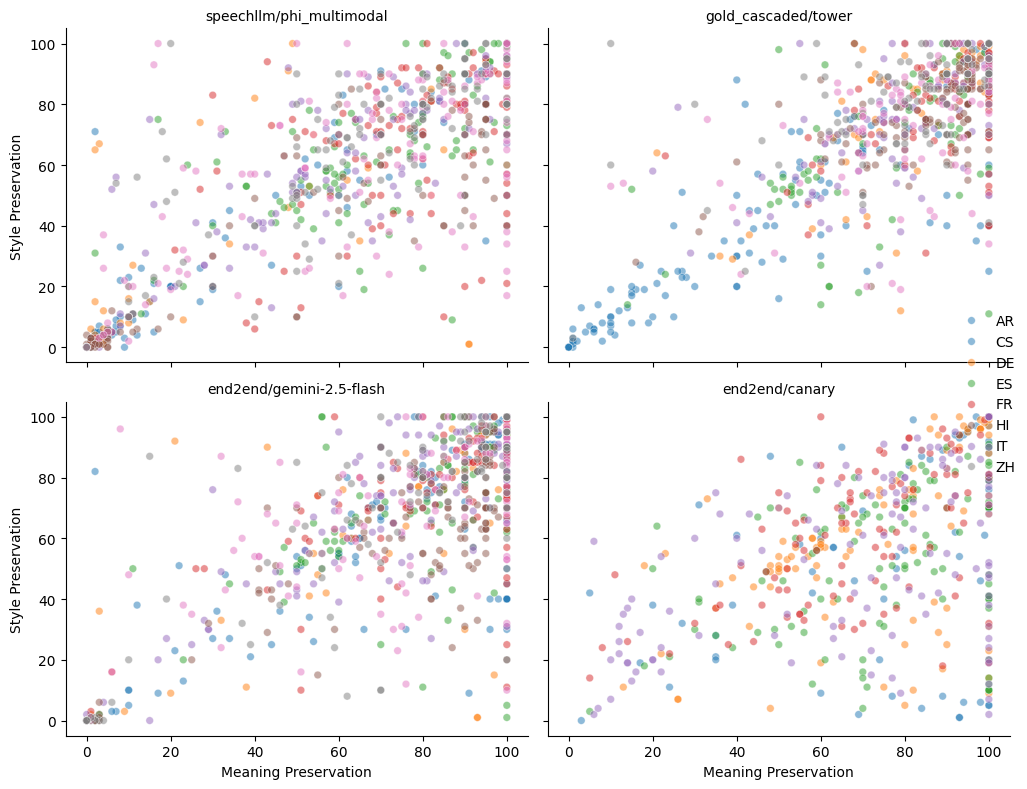

In [4]:
# --- Style vs Meaning scatter (per model) ---
g = sns.FacetGrid(df, col='model', col_wrap=2, height=4, aspect=1.2)
g.map_dataframe(sns.scatterplot, x='meaning', y='style', hue='lang', alpha=0.5, s=30)
g.add_legend()
g.set_axis_labels('Meaning Preservation', 'Style Preservation')
g.set_titles('{col_name}')
plt.tight_layout()
plt.show()

4364 total error spans


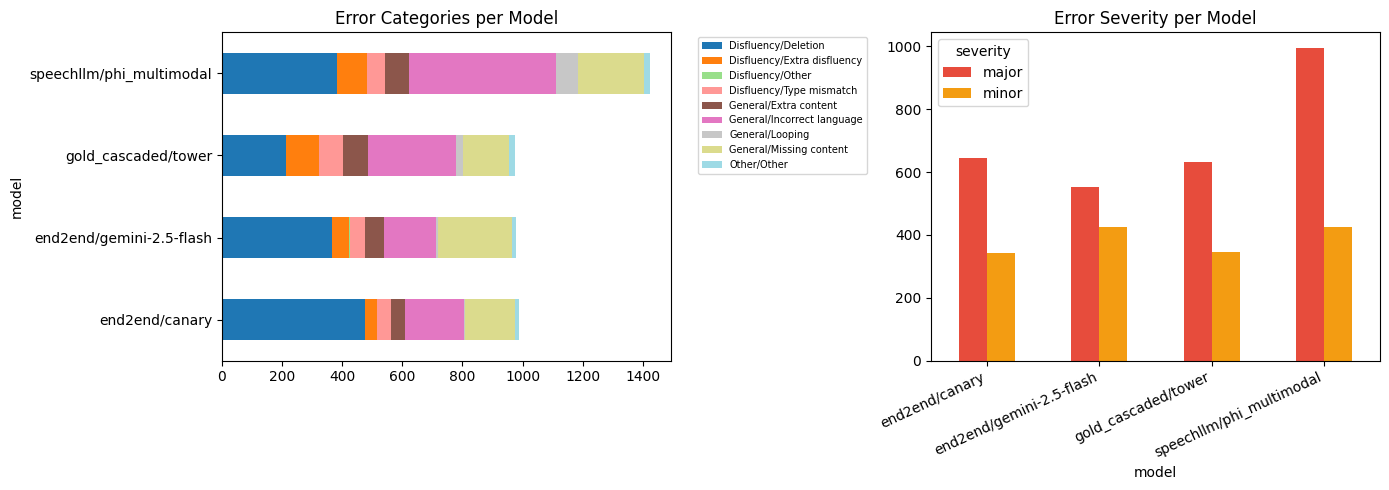

In [5]:
# --- Error span analysis ---
# Explode error categories
err_rows = []
for _, row in df.iterrows():
    for cat, sev in zip(row['error_cats'], row['error_sevs']):
        err_rows.append({'lang': row['lang'], 'model': row['model'], 'category': cat, 'severity': sev})

df_err = pd.DataFrame(err_rows)
print(f'{len(df_err)} total error spans')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error category counts per model
ct = df_err.groupby(['model', 'category']).size().unstack(fill_value=0)
ct.plot.barh(stacked=True, ax=axes[0], colormap='tab20')
axes[0].set_title('Error Categories per Model')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

# Severity breakdown per model
sv = df_err.groupby(['model', 'severity']).size().unstack(fill_value=0)
sv.plot.bar(ax=axes[1], color=['#e74c3c', '#f39c12'])
axes[1].set_title('Error Severity per Model')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha='right')

plt.tight_layout()
plt.show()

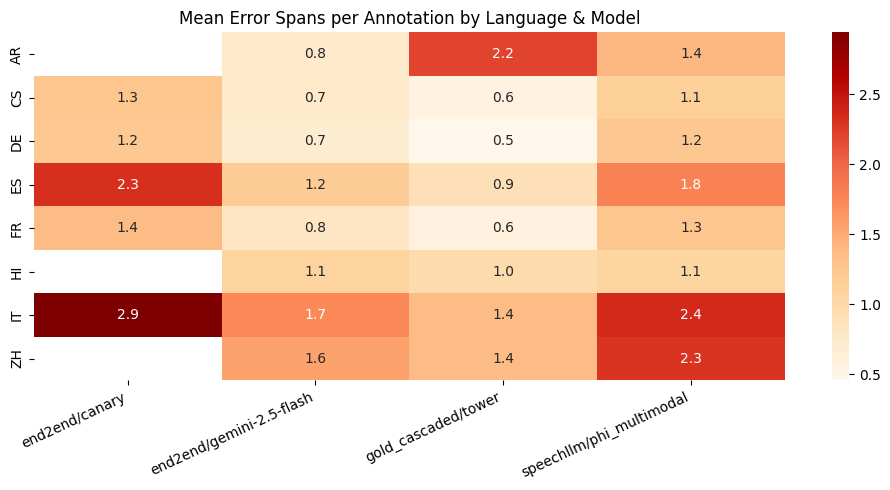

In [6]:
# --- Mean number of errors per model per language ---
pivot_err = df.pivot_table(index='lang', columns='model', values='n_errors', aggfunc='mean')
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_err, annot=True, fmt='.1f', cmap='OrRd', ax=ax)
ax.set_title('Mean Error Spans per Annotation by Language & Model')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
plt.tight_layout()
plt.show()

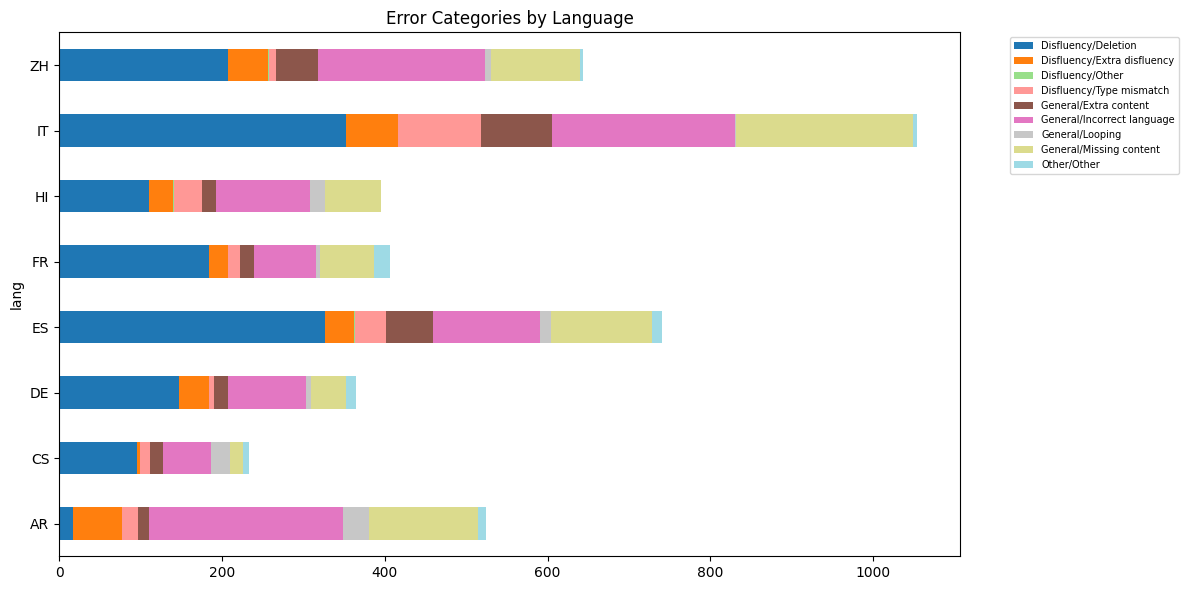

In [7]:
# --- Error categories by language ---
ct_lang = df_err.groupby(['lang', 'category']).size().unstack(fill_value=0)
ct_lang.plot.barh(stacked=True, figsize=(12, 6), colormap='tab20')
plt.title('Error Categories by Language')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

In [8]:
# --- Summary table ---
summary = df.groupby('model').agg(
    n_annotations=('style', 'count'),
    mean_style=('style', 'mean'),
    mean_meaning=('meaning', 'mean'),
    mean_errors=('n_errors', 'mean'),
).round(1)
summary

,n_annotations,mean_style,mean_meaning,mean_errors
model,,,,
end2end/canary,510,56.7,71.0,1.9
end2end/gemini-2.5-flash,880,68.8,76.3,1.1
gold_cascaded/tower,880,74.2,79.2,1.1
speechllm/phi_multimodal,880,51.5,54.9,1.6


## Inter-Annotator Agreement (_r0, _r1, _r2)

1614 rows from _r0/_r1/_r2 annotators
Unique rounds: ['r0', 'r1', 'r2']
Languages with repeated annotations: ['AR', 'CS', 'DE', 'ES', 'FR', 'HI', 'IT', 'ZH']

580 item-model groups with 2+ annotators


/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_30204/1883602816.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_agree, x='model', y=col, ax=ax, palette='Set2')
/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_30204/1883602816.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_30204/1883602816.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_agree, x='model', y=col, ax=ax, palette='Set2')
/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/

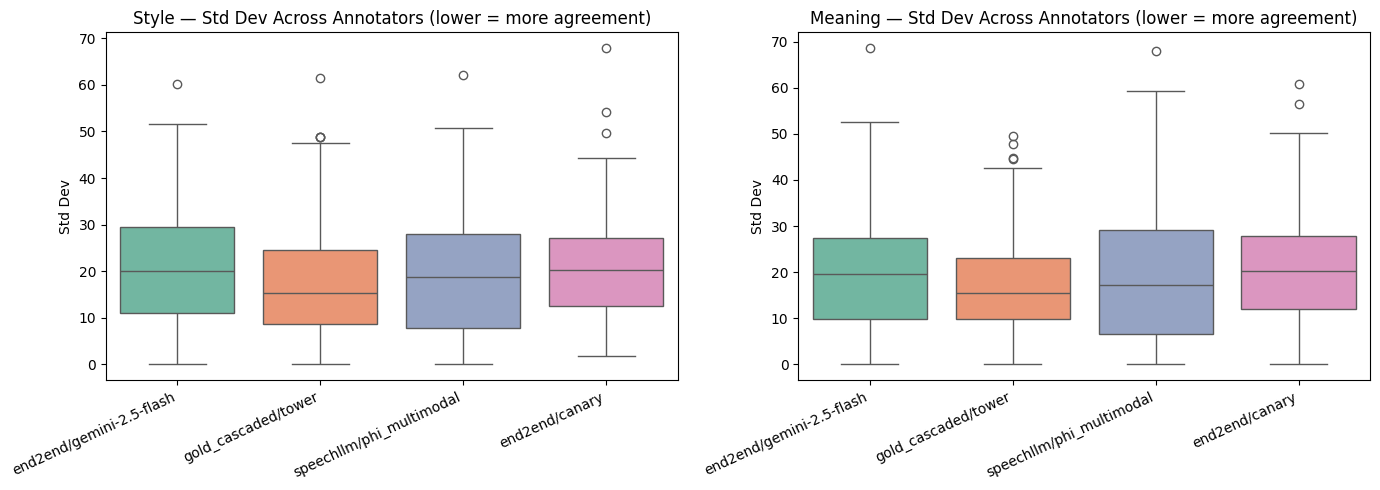

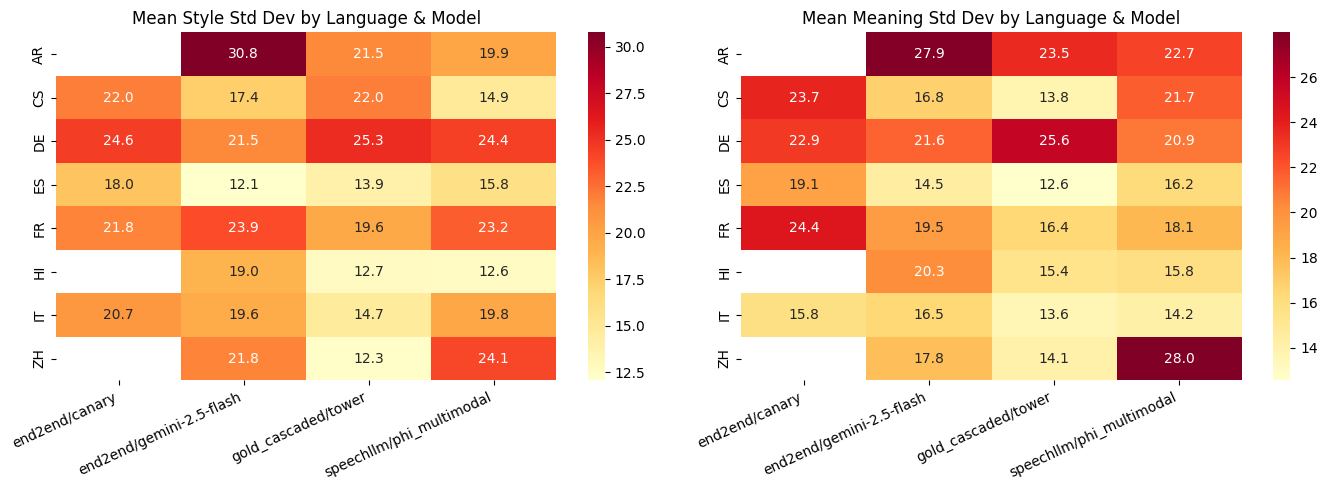

In [9]:
# --- Inter-Annotator Agreement for _r0, _r1, _r2 annotators ---
# These user_ids share the same item range (1..20) with different annotators

# Filter to only _r0, _r1, _r2 annotators
df_r = df[df['user_id'].str.contains('_r[012]$', regex=True)].copy()
df_r['round'] = df_r['user_id'].str.extract(r'_(r\d)$')[0]
print(f'{len(df_r)} rows from _r0/_r1/_r2 annotators')
print(f'Unique rounds: {sorted(df_r["round"].unique())}')
print(f'Languages with repeated annotations: {sorted(df_r["lang"].unique())}')

# Compute per-item std across annotators (for each lang x model x item)
agreement_rows = []
for (lang, model, item_i), grp in df_r.groupby(['lang', 'model', 'item_i']):
    if len(grp) >= 2:
        agreement_rows.append({
            'lang': lang, 'model': model, 'item_i': item_i,
            'n_annotators': len(grp),
            'style_std': grp['style'].std(),
            'meaning_std': grp['meaning'].std(),
            'style_range': grp['style'].max() - grp['style'].min(),
            'meaning_range': grp['meaning'].max() - grp['meaning'].min(),
        })

df_agree = pd.DataFrame(agreement_rows)
print(f'\n{len(df_agree)} item-model groups with 2+ annotators')

# Plot std distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes, ['style_std', 'meaning_std'], ['Style', 'Meaning']):
    sns.boxplot(data=df_agree, x='model', y=col, ax=ax, palette='Set2')
    ax.set_title(f'{title} — Std Dev Across Annotators (lower = more agreement)')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
    ax.set_ylabel('Std Dev')
plt.tight_layout()
plt.show()

# Heatmap of mean std by lang x model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes, ['style_std', 'meaning_std'], ['Style', 'Meaning']):
    pivot = df_agree.pivot_table(index='lang', columns='model', values=col, aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
    ax.set_title(f'Mean {title} Std Dev by Language & Model')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
plt.tight_layout()
plt.show()

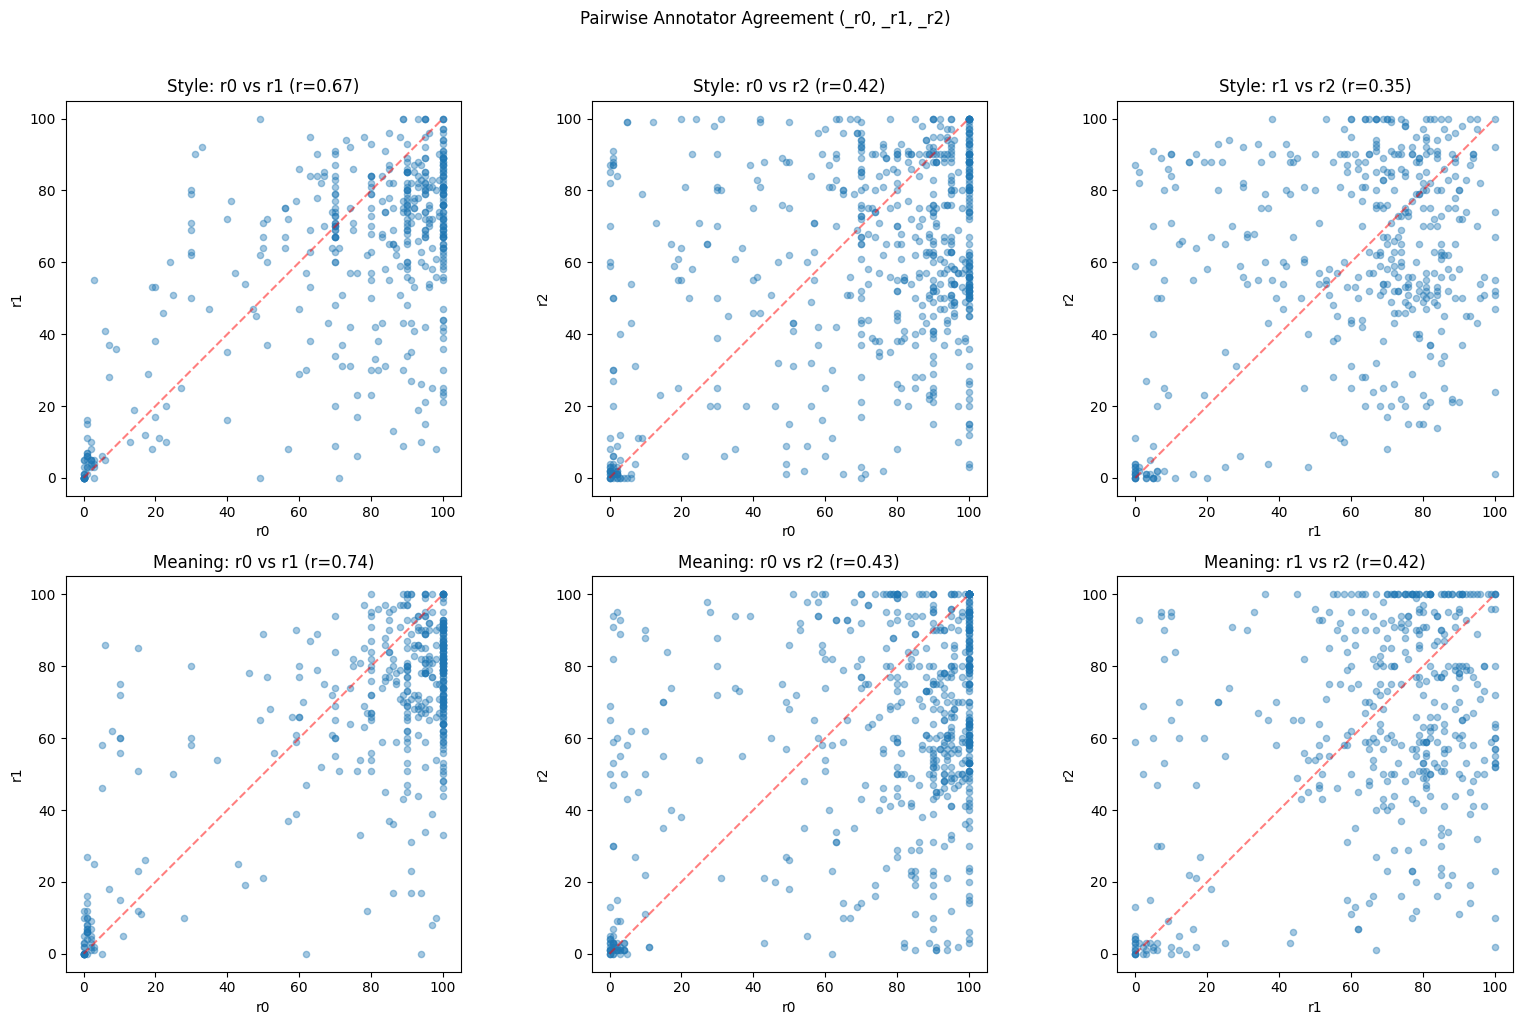

In [10]:
# --- Pairwise agreement: scatter r0 vs r1, r0 vs r2, r1 vs r2 ---
import itertools

pairs = list(itertools.combinations(['r0', 'r1', 'r2'], 2))
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col_i, (ra, rb) in enumerate(pairs):
    for row_i, metric in enumerate(['style', 'meaning']):
        ax = axes[row_i, col_i]
        # Merge on lang, model, item_i
        da = df_r[df_r['round'] == ra][['lang', 'model', 'item_i', metric]].rename(columns={metric: f'{metric}_{ra}'})
        db = df_r[df_r['round'] == rb][['lang', 'model', 'item_i', metric]].rename(columns={metric: f'{metric}_{rb}'})
        merged = da.merge(db, on=['lang', 'model', 'item_i'])
        if len(merged) > 0:
            ax.scatter(merged[f'{metric}_{ra}'], merged[f'{metric}_{rb}'], alpha=0.4, s=20)
            ax.plot([0, 100], [0, 100], 'r--', alpha=0.5)
            corr = merged[f'{metric}_{ra}'].corr(merged[f'{metric}_{rb}'])
            ax.set_title(f'{metric.title()}: {ra} vs {rb} (r={corr:.2f})')
        ax.set_xlabel(ra)
        ax.set_ylabel(rb)
        ax.set_xlim(-5, 105)
        ax.set_ylim(-5, 105)
        ax.set_aspect('equal')

plt.suptitle('Pairwise Annotator Agreement (_r0, _r1, _r2)', y=1.02)
plt.tight_layout()
plt.show()

## Annotation Time

880 timed annotations (capped at 1h)
Median: 170s, Mean: 231s


/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_30204/1138238761.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_time, x='lang', y='duration_min', ax=axes[1], palette='Set2')


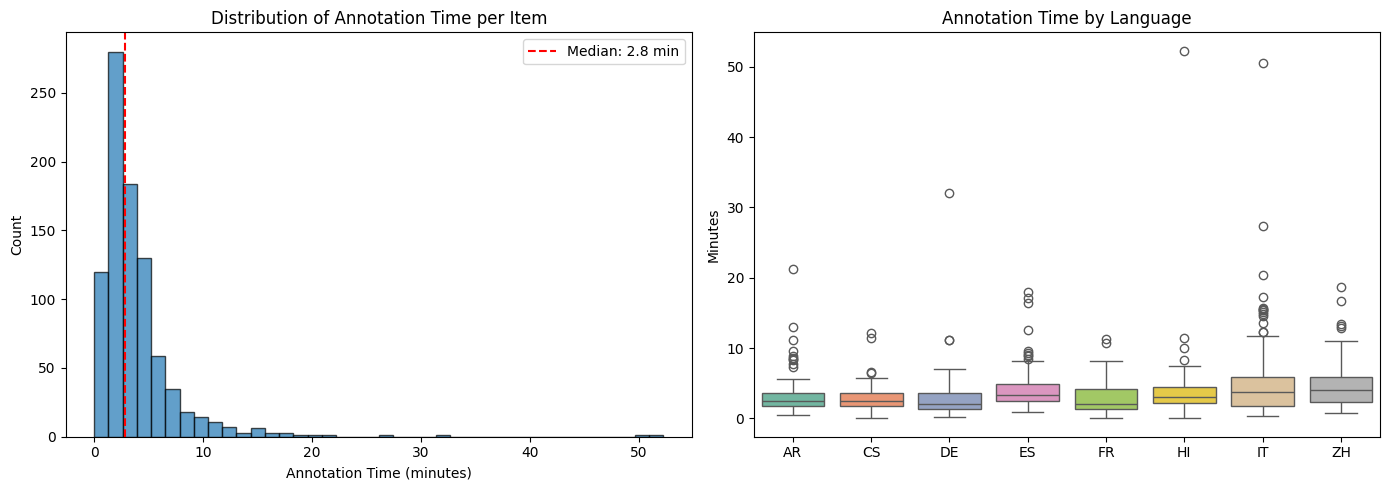

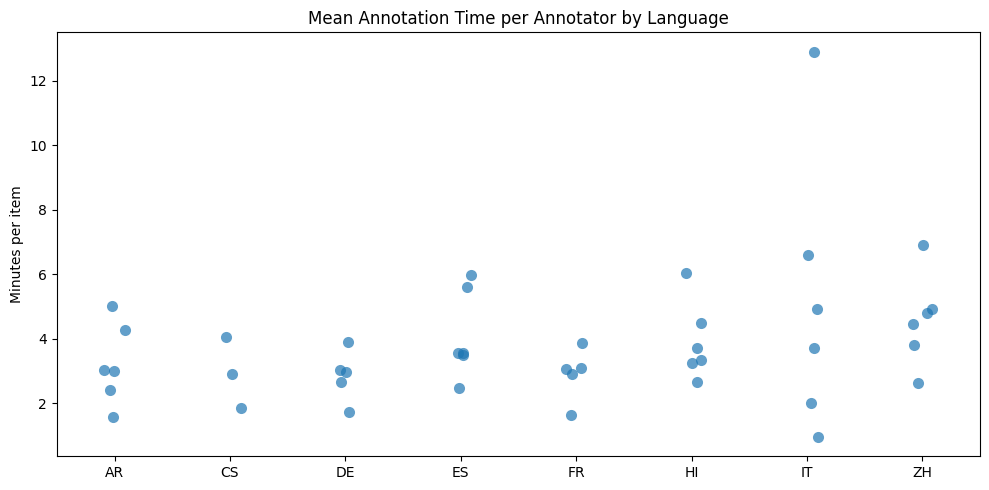

In [11]:
# --- Annotation time (load → submit) ---
time_rows = []
for lang_key, entries in raw.items():
    lang = lang_key.replace('uhmazing_v1_', '').upper()
    for entry in entries:
        item_i = entry.get('item_i')
        if not isinstance(item_i, int):
            continue
        ann = entry.get('annotation')
        if not isinstance(ann, list) or len(ann) == 0 or not isinstance(ann[0], dict):
            continue
        actions = entry.get('actions', [])
        load_t = None
        submit_t = None
        for a in actions:
            if a.get('action') == 'load' and load_t is None:
                load_t = a['time']
            if a.get('action') == 'submit':
                submit_t = a['time']
        if load_t and submit_t and submit_t > load_t:
            duration = submit_t - load_t
            if duration < 3600:  # cap at 1h to exclude abandoned sessions
                time_rows.append({
                    'lang': lang,
                    'user_id': entry.get('user_id'),
                    'item_i': item_i,
                    'duration_s': duration,
                    'duration_min': duration / 60,
                })

df_time = pd.DataFrame(time_rows)
print(f'{len(df_time)} timed annotations (capped at 1h)')
print(f'Median: {df_time["duration_s"].median():.0f}s, Mean: {df_time["duration_s"].mean():.0f}s')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of annotation time
axes[0].hist(df_time['duration_min'], bins=40, edgecolor='black', alpha=0.7)
axes[0].axvline(df_time['duration_min'].median(), color='red', linestyle='--', label=f'Median: {df_time["duration_min"].median():.1f} min')
axes[0].set_xlabel('Annotation Time (minutes)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Annotation Time per Item')
axes[0].legend()

# By language
sns.boxplot(data=df_time, x='lang', y='duration_min', ax=axes[1], palette='Set2')
axes[1].set_title('Annotation Time by Language')
axes[1].set_xlabel('')
axes[1].set_ylabel('Minutes')

plt.tight_layout()
plt.show()

# Per-user average annotation time
user_avg = df_time.groupby(['lang', 'user_id'])['duration_min'].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
sns.stripplot(data=user_avg, x='lang', y='duration_min', ax=ax, jitter=True, alpha=0.7, size=8)
ax.set_title('Mean Annotation Time per Annotator by Language')
ax.set_xlabel('')
ax.set_ylabel('Minutes per item')
plt.tight_layout()
plt.show()

## Annotator Profiles

47 annotator profiles across 8 languages


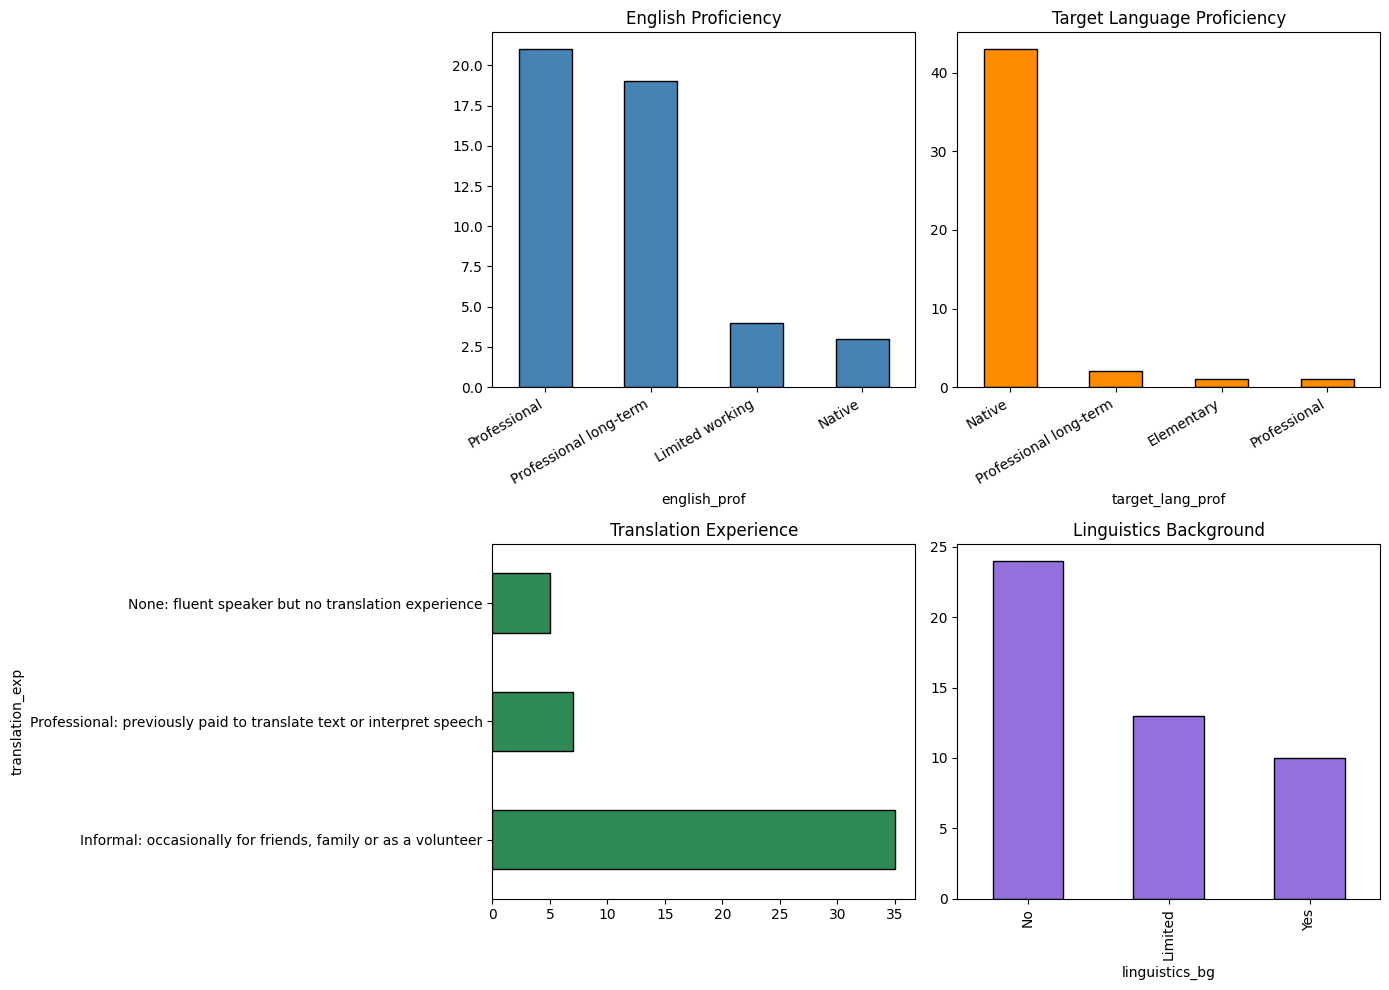

In [12]:
# --- Annotator profiles from welcome_0 entries ---
# Fields: [None, prolific_id, native_lang, english_prof, target_lang_prof, translation_exp, linguistics_bg]
profile_rows = []
for lang_key, entries in raw.items():
    lang = lang_key.replace('uhmazing_v1_', '').upper()
    for entry in entries:
        if entry.get('item_i') != 'welcome_0':
            continue
        ann = entry.get('annotation')
        if not isinstance(ann, list) or len(ann) < 7:
            continue
        # skip test/dummy entries
        if ann[1] in (None, 'ts', ''):
            continue
        profile_rows.append({
            'lang': lang,
            'user_id': entry.get('user_id'),
            'prolific_id': ann[1],
            'native_lang': ann[2],
            'english_prof': ann[3],
            'target_lang_prof': ann[4],
            'translation_exp': ann[5],
            'linguistics_bg': ann[6],
        })

df_prof = pd.DataFrame(profile_rows)
# Deduplicate by prolific_id (same person may appear in same lang group)
df_prof = df_prof.drop_duplicates(subset=['lang', 'prolific_id'])
print(f'{len(df_prof)} annotator profiles across {df_prof.lang.nunique()} languages')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# English proficiency
df_prof['english_prof'].value_counts().plot.bar(ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_title('English Proficiency')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=30, ha='right')

# Target language proficiency
df_prof['target_lang_prof'].value_counts().plot.bar(ax=axes[0, 1], color='darkorange', edgecolor='black')
axes[0, 1].set_title('Target Language Proficiency')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=30, ha='right')

# Translation experience
df_prof['translation_exp'].value_counts().plot.barh(ax=axes[1, 0], color='seagreen', edgecolor='black')
axes[1, 0].set_title('Translation Experience')

# Linguistics background
df_prof['linguistics_bg'].value_counts().plot.bar(ax=axes[1, 1], color='mediumpurple', edgecolor='black')
axes[1, 1].set_title('Linguistics Background')

plt.tight_layout()
plt.show()

43 annotators with both profile and scores


/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_30204/3937549639.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_prof_scores, x='english_prof', y='mean_style', ax=axes[0, 0],
/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_30204/3937549639.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=25, ha='right')
/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_30204/3937549639.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_prof_scores, x='target_lang_prof', y='mean_meaning', ax=axes[0, 1],

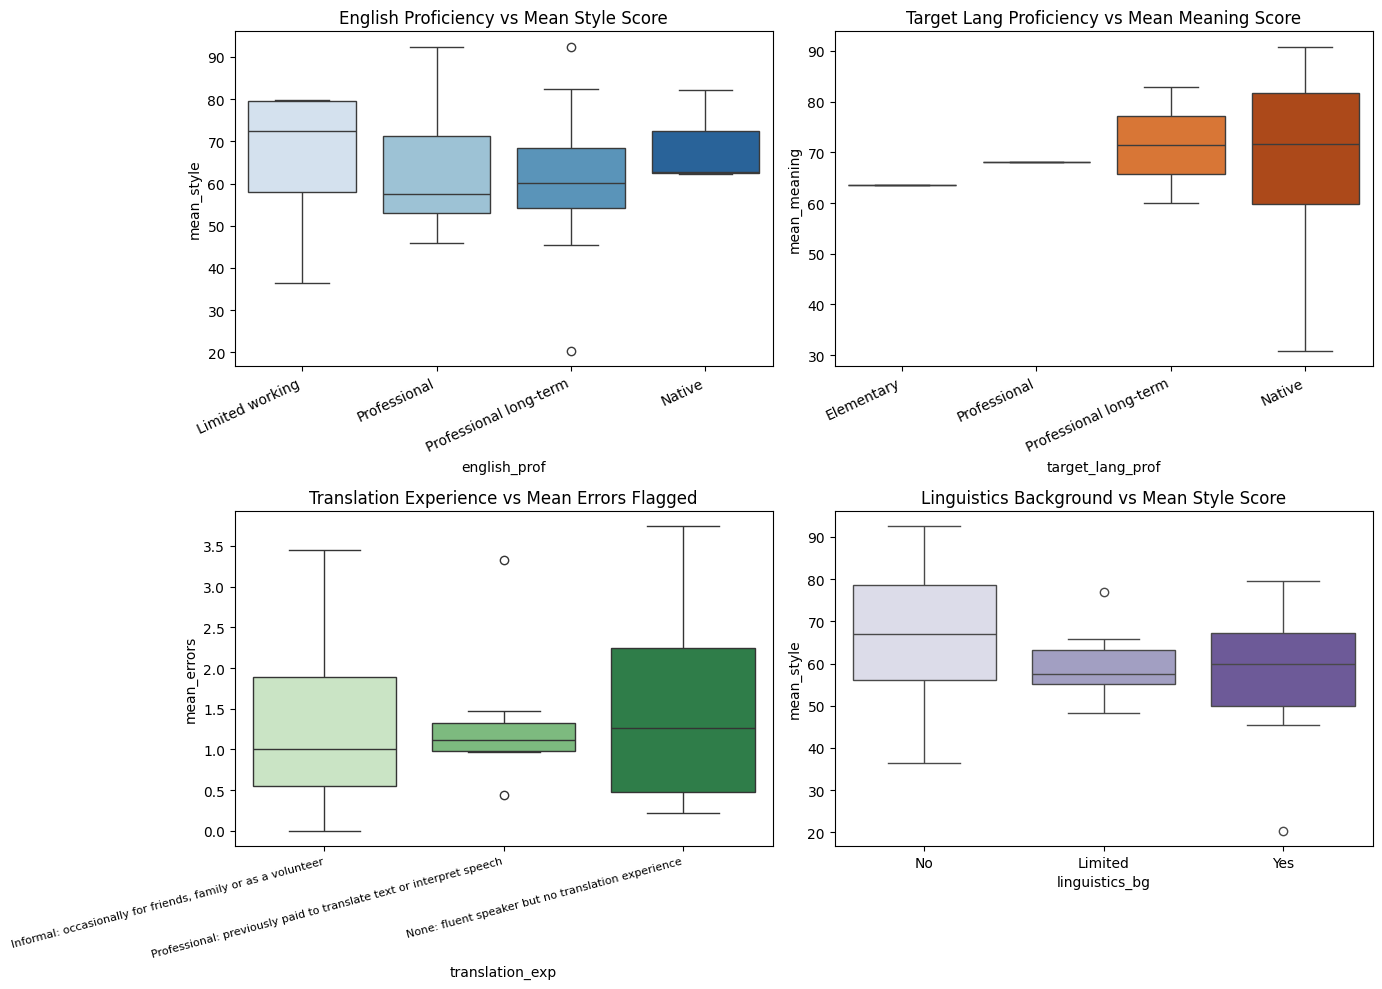

In [13]:
# --- Correlate annotator profiles with scoring patterns ---
# Merge profiles with per-annotator mean scores
annotator_means = df.groupby(['lang', 'user_id']).agg(
    mean_style=('style', 'mean'),
    mean_meaning=('meaning', 'mean'),
    mean_errors=('n_errors', 'mean'),
).reset_index()

df_prof_scores = df_prof.merge(annotator_means, on=['lang', 'user_id'], how='inner')
print(f'{len(df_prof_scores)} annotators with both profile and scores')

# Proficiency order for plotting
prof_order = ['Elementary', 'Limited working', 'Professional', 'Professional long-term', 'Native']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# English proficiency vs mean style
sns.boxplot(data=df_prof_scores, x='english_prof', y='mean_style', ax=axes[0, 0],
            order=[p for p in prof_order if p in df_prof_scores['english_prof'].values], palette='Blues')
axes[0, 0].set_title('English Proficiency vs Mean Style Score')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=25, ha='right')

# Target lang proficiency vs mean meaning
sns.boxplot(data=df_prof_scores, x='target_lang_prof', y='mean_meaning', ax=axes[0, 1],
            order=[p for p in prof_order if p in df_prof_scores['target_lang_prof'].values], palette='Oranges')
axes[0, 1].set_title('Target Lang Proficiency vs Mean Meaning Score')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=25, ha='right')

# Translation experience vs mean errors
sns.boxplot(data=df_prof_scores, x='translation_exp', y='mean_errors', ax=axes[1, 0], palette='Greens')
axes[1, 0].set_title('Translation Experience vs Mean Errors Flagged')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=15, ha='right', fontsize=8)

# Linguistics background vs mean style
sns.boxplot(data=df_prof_scores, x='linguistics_bg', y='mean_style', ax=axes[1, 1],
            order=['No', 'Limited', 'Yes'], palette='Purples')
axes[1, 1].set_title('Linguistics Background vs Mean Style Score')

plt.tight_layout()
plt.show()

## Error Span Length

4364 error spans total
Span length — min: 0, median: 2, mean: 30, max: 8097


/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_30204/2351448575.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_spans, x='model', y='span_len', ax=axes[0, 1], palette='Set2',
/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_30204/2351448575.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=25, ha='right')
/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_30204/2351448575.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_spans, y='category', x='span_len', ax=axes[1, 0], palette='tab10',

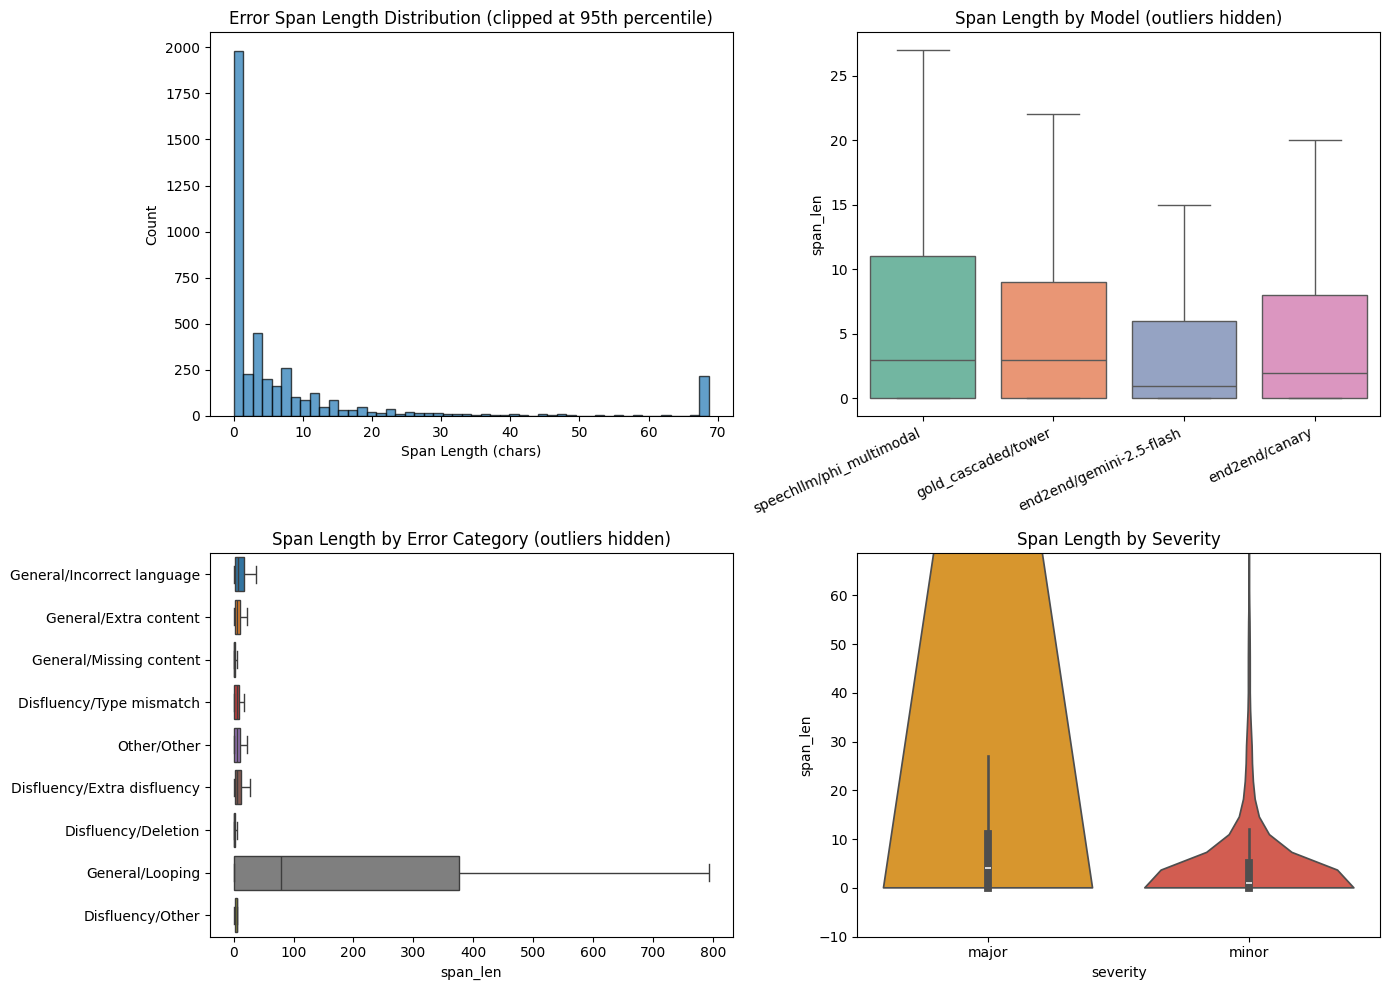

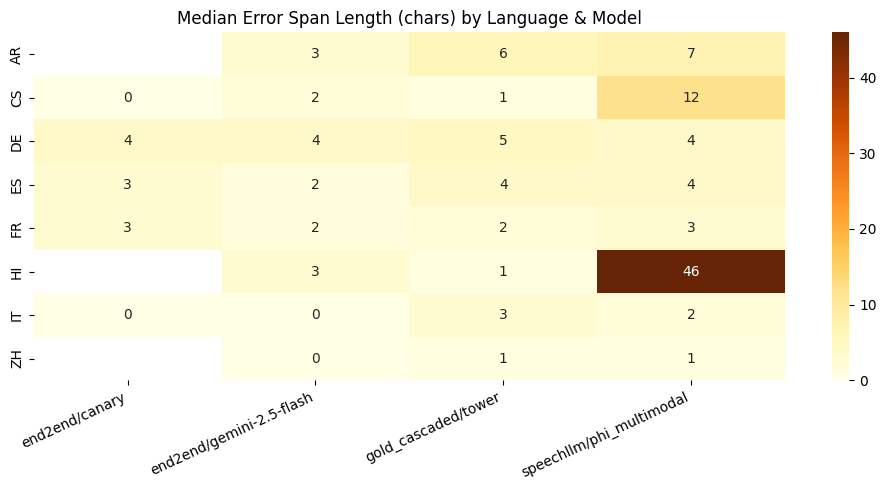

In [14]:
# --- Error span length analysis (character-level) ---
span_rows = []
for lang_key, entries in raw.items():
    lang = lang_key.replace('uhmazing_v1_', '').upper()
    for entry in entries:
        item_i = entry.get('item_i')
        ann = entry.get('annotation')
        if not isinstance(item_i, int) or not isinstance(ann, list):
            continue
        for ann_dict in ann:
            if not isinstance(ann_dict, dict):
                continue
            for model, mdata in ann_dict.items():
                if not isinstance(mdata, dict) or 'sliders' not in mdata:
                    continue
                for span in mdata.get('error_spans', []):
                    span_len = span['end_i'] - span['start_i']
                    span_rows.append({
                        'lang': lang,
                        'model': model,
                        'item_i': item_i,
                        'category': span.get('category'),
                        'severity': span.get('severity'),
                        'span_len': span_len,
                    })

df_spans = pd.DataFrame(span_rows)
print(f'{len(df_spans)} error spans total')
print(f'Span length — min: {df_spans["span_len"].min()}, median: {df_spans["span_len"].median():.0f}, '
      f'mean: {df_spans["span_len"].mean():.0f}, max: {df_spans["span_len"].max()}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of span lengths (log scale since very skewed)
axes[0, 0].hist(df_spans['span_len'].clip(upper=df_spans['span_len'].quantile(0.95)),
                bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Error Span Length Distribution (clipped at 95th percentile)')
axes[0, 0].set_xlabel('Span Length (chars)')
axes[0, 0].set_ylabel('Count')

# Span length by model
sns.boxplot(data=df_spans, x='model', y='span_len', ax=axes[0, 1], palette='Set2',
            showfliers=False)
axes[0, 1].set_title('Span Length by Model (outliers hidden)')
axes[0, 1].set_xlabel('')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=25, ha='right')

# Span length by error category
sns.boxplot(data=df_spans, y='category', x='span_len', ax=axes[1, 0], palette='tab10',
            showfliers=False)
axes[1, 0].set_title('Span Length by Error Category (outliers hidden)')
axes[1, 0].set_ylabel('')

# Span length by severity
sns.violinplot(data=df_spans, x='severity', y='span_len', ax=axes[1, 1],
               palette=['#f39c12', '#e74c3c'], cut=0, inner='box')
axes[1, 1].set_title('Span Length by Severity')
axes[1, 1].set_ylim(-10, df_spans['span_len'].quantile(0.95))

plt.tight_layout()
plt.show()

# Heatmap: median span length by model x language
pivot_span = df_spans.pivot_table(index='lang', columns='model', values='span_len', aggfunc='median')
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_span, annot=True, fmt='.0f', cmap='YlOrBr', ax=ax)
ax.set_title('Median Error Span Length (chars) by Language & Model')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
plt.tight_layout()
plt.show()